In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def load_combined_data(og_dir, retrain_dir):
    og_dfs = []
    retrain_dfs = []
    
    # Load original data
    og_path = Path(og_dir)
    for ckpt_dir in og_path.glob("ckpt_*"):
        if "to" in ckpt_dir.name:
            continue
        
        for summary_file in ckpt_dir.glob("fast_eval_*/summary.tsv"):
            df = pd.read_csv(summary_file, sep="\t")
            step = ckpt_dir.name.replace("ckpt_", "")
            df["step"] = step
            df["config"] = "original"
            og_dfs.append(df)
        
    # Load retrained data
    retrain_path = Path(retrain_dir)
    for ckpt_dir in retrain_path.glob("ckpt_*"):
        if "to" in ckpt_dir.name:
            continue
        
        for summary_file in ckpt_dir.glob("fast_eval_*/summary.tsv"):
                df = pd.read_csv(summary_file, sep='\t')
                step = ckpt_dir.name.replace("ckpt_", "")
                df["step"] = step
                df["config"] = "retrained"
                retrain_dfs.append(df)
        
    # Combine all data
    combined_df = pd.concat(og_dfs + retrain_dfs, ignore_index=True)
    return combined_df

In [3]:
# Load data
scratch_dir = "/data/ratna/from_scratch/eval_results"
retrain_dir = "/data/ratna/retrain/eval_results"
combined_df = load_combined_data(scratch_dir, retrain_dir)
combined_df.head()

,dataset,mode,status,elapsed_sec,metric,metric_mean,runs,start,end,results_json,log_file,step,config
0,bach,predict_fit,ok,395,val/MulticlassAccuracy,0.298676,"run_1=0.282835, run_2=0.314516",2026-03-23T18:23:20+00:00,2026-03-23T18:29:55+00:00,/admin/home/ratna/OpenMidnight/eval_results/ck...,/admin/home/ratna/OpenMidnight/eval_results/ck...,0,original
1,bracs,predict_fit,ok,423,test/MulticlassAccuracy,0.149165,"run_1=0.155189, run_2=0.143141",2026-03-23T18:29:55+00:00,2026-03-23T18:36:58+00:00,/admin/home/ratna/OpenMidnight/eval_results/ck...,/admin/home/ratna/OpenMidnight/eval_results/ck...,0,original
2,breakhist,predict_fit,ok,202,val/MulticlassAccuracy,0.250000,"run_1=0.250000, run_2=0.250000",2026-03-23T18:36:58+00:00,2026-03-23T18:40:20+00:00,/admin/home/ratna/OpenMidnight/eval_results/ck...,/admin/home/ratna/OpenMidnight/eval_results/ck...,0,original
3,crc,predict_fit,ok,1598,val/MulticlassAccuracy,0.111111,"run_1=0.111111, run_2=0.111111",2026-03-23T18:40:21+00:00,2026-03-23T19:06:59+00:00,/admin/home/ratna/OpenMidnight/eval_results/ck...,/admin/home/ratna/OpenMidnight/eval_results/ck...,0,original
4,gleason,predict_fit,ok,396,val/MulticlassAccuracy,0.250000,"run_1=0.250000, run_2=0.250000",2026-03-23T19:06:59+00:00,2026-03-23T19:13:35+00:00,/admin/home/ratna/OpenMidnight/eval_results/ck...,/admin/home/ratna/OpenMidnight/eval_results/ck...,0,original


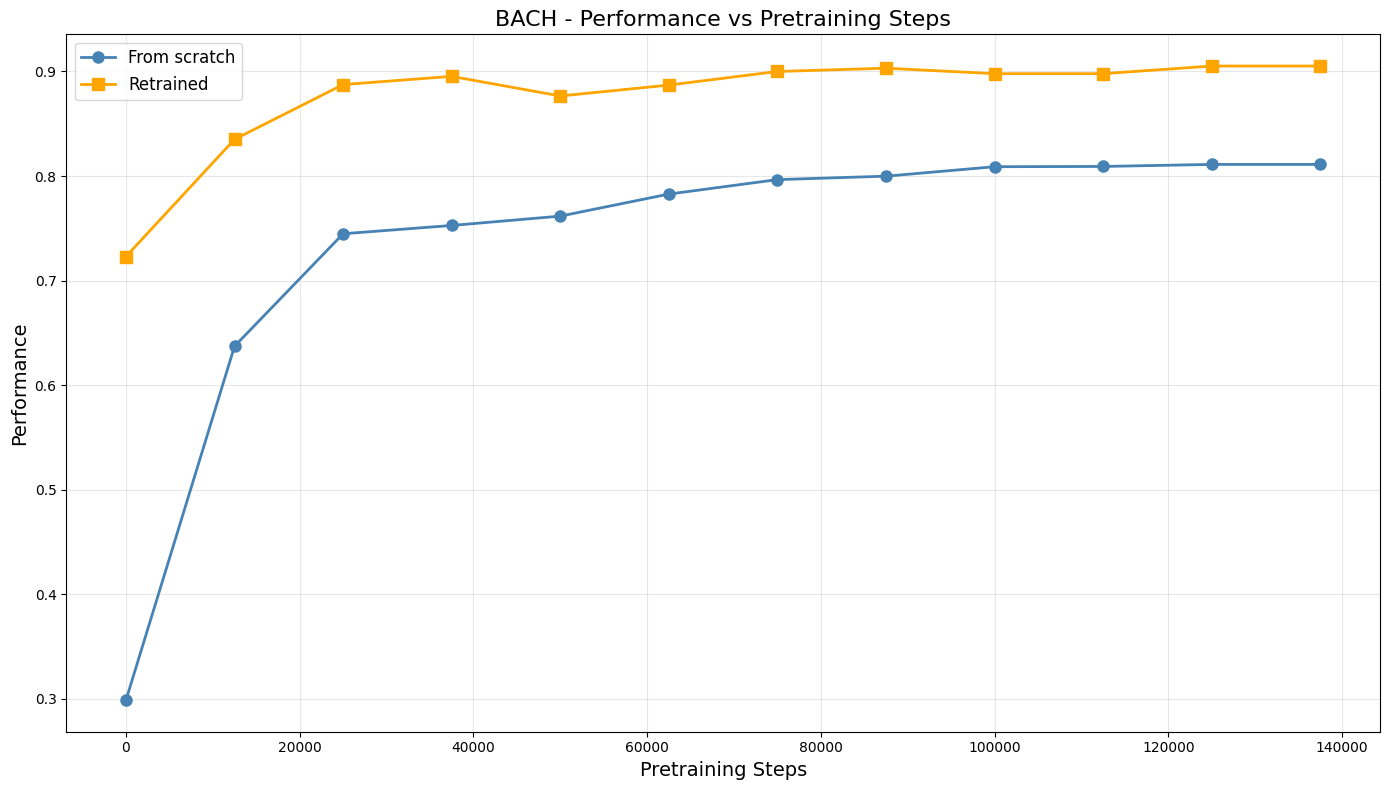

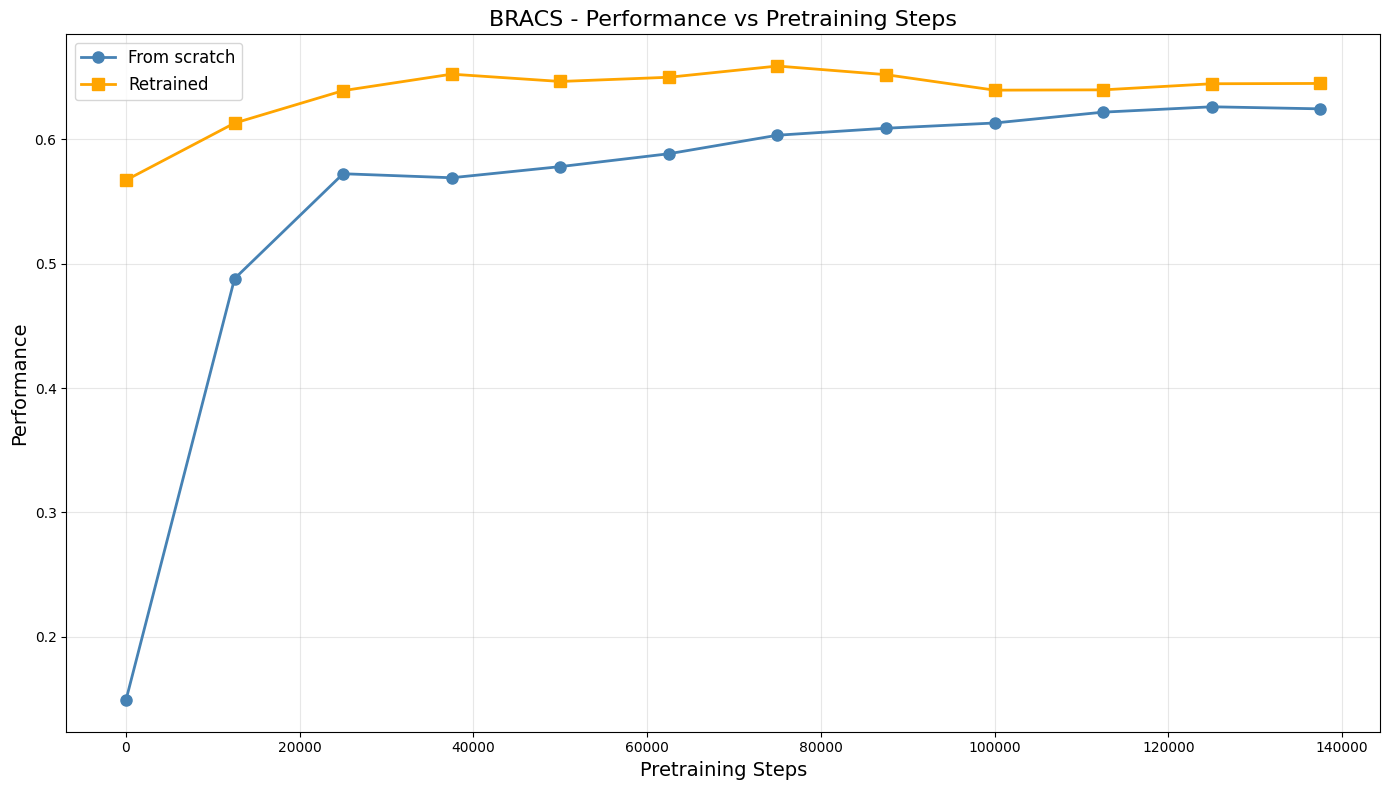

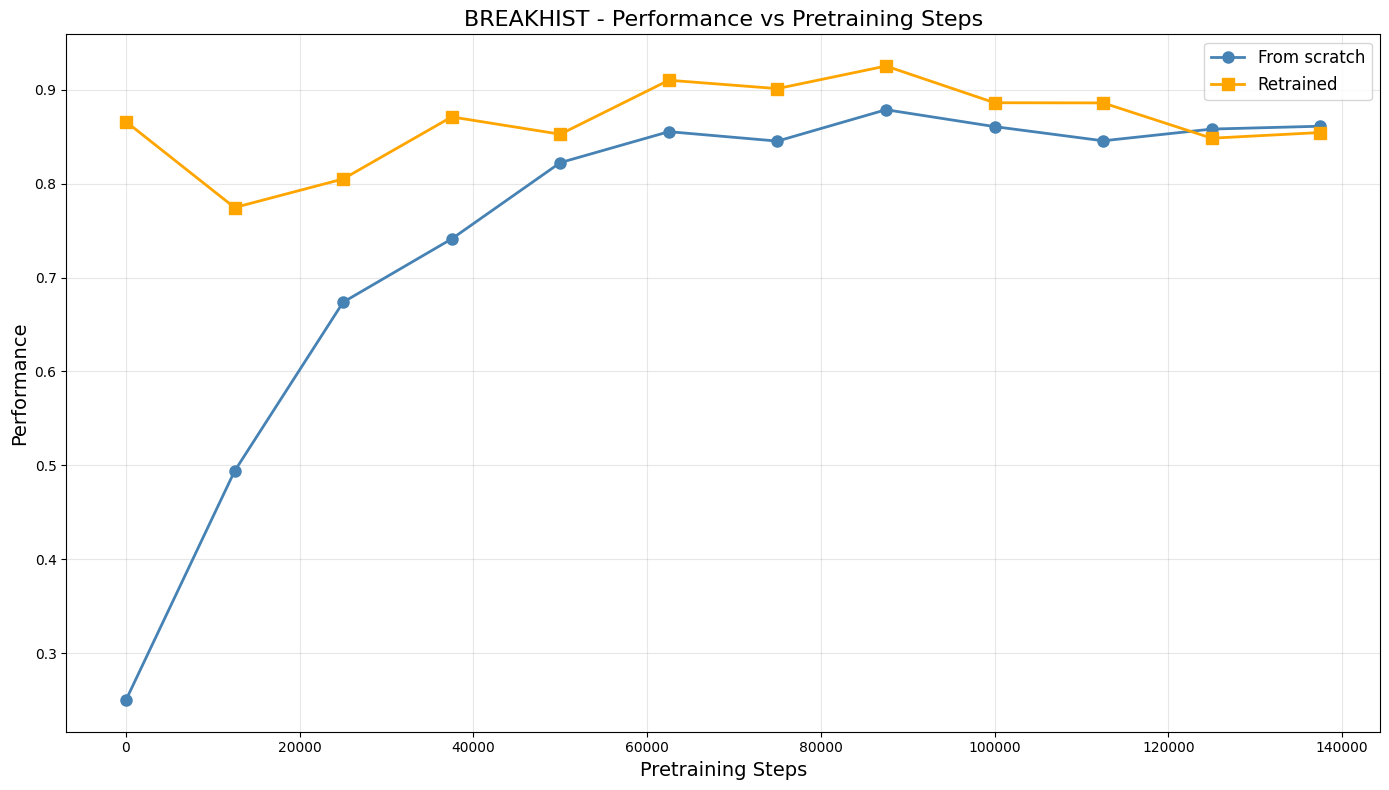

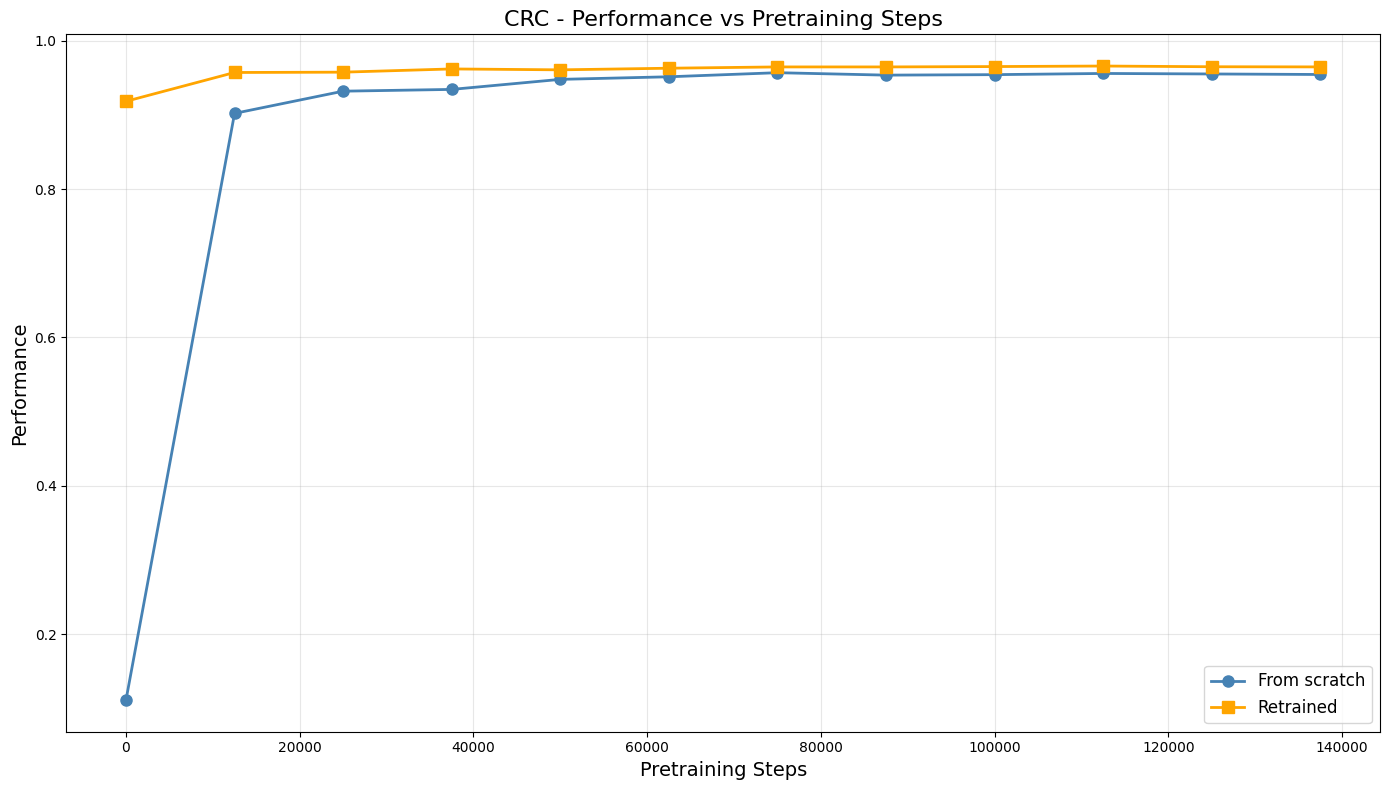

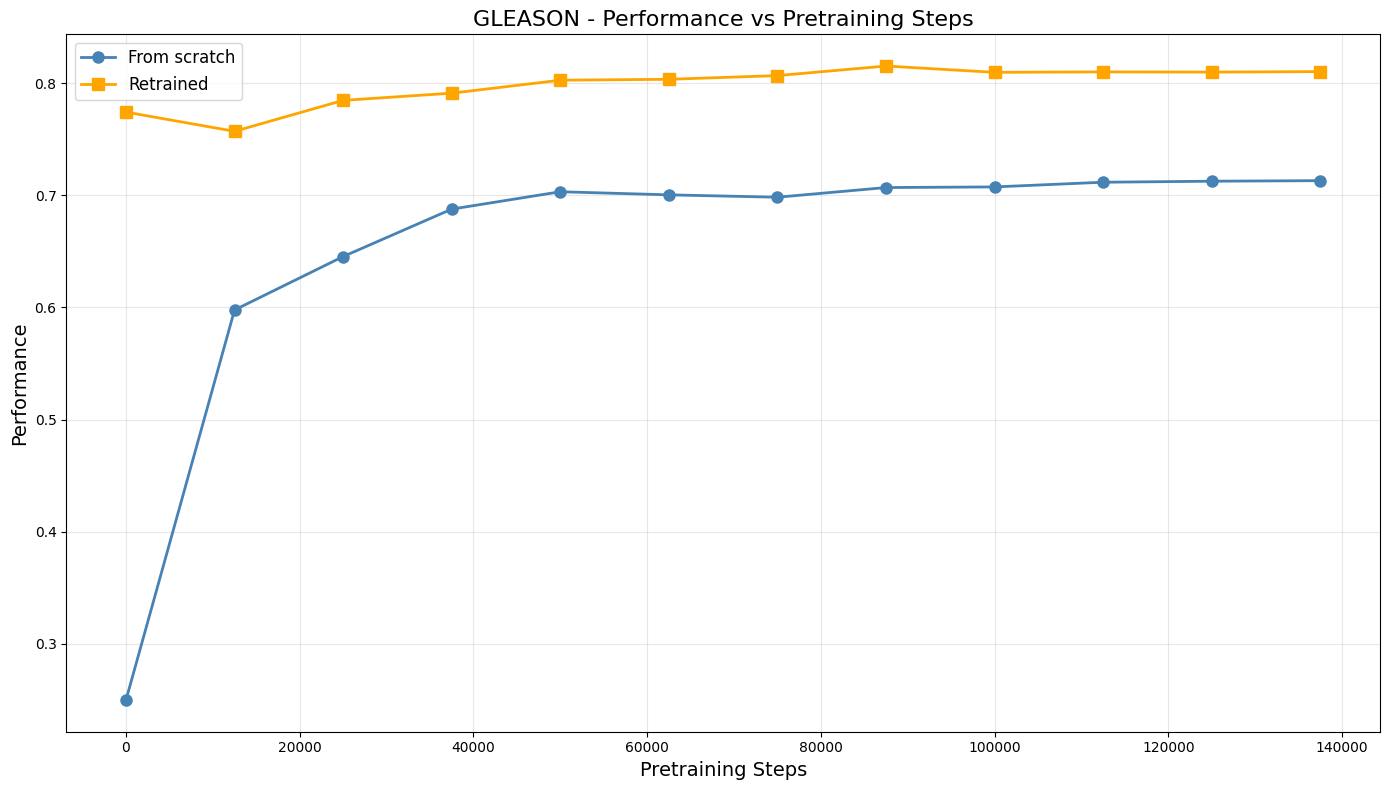

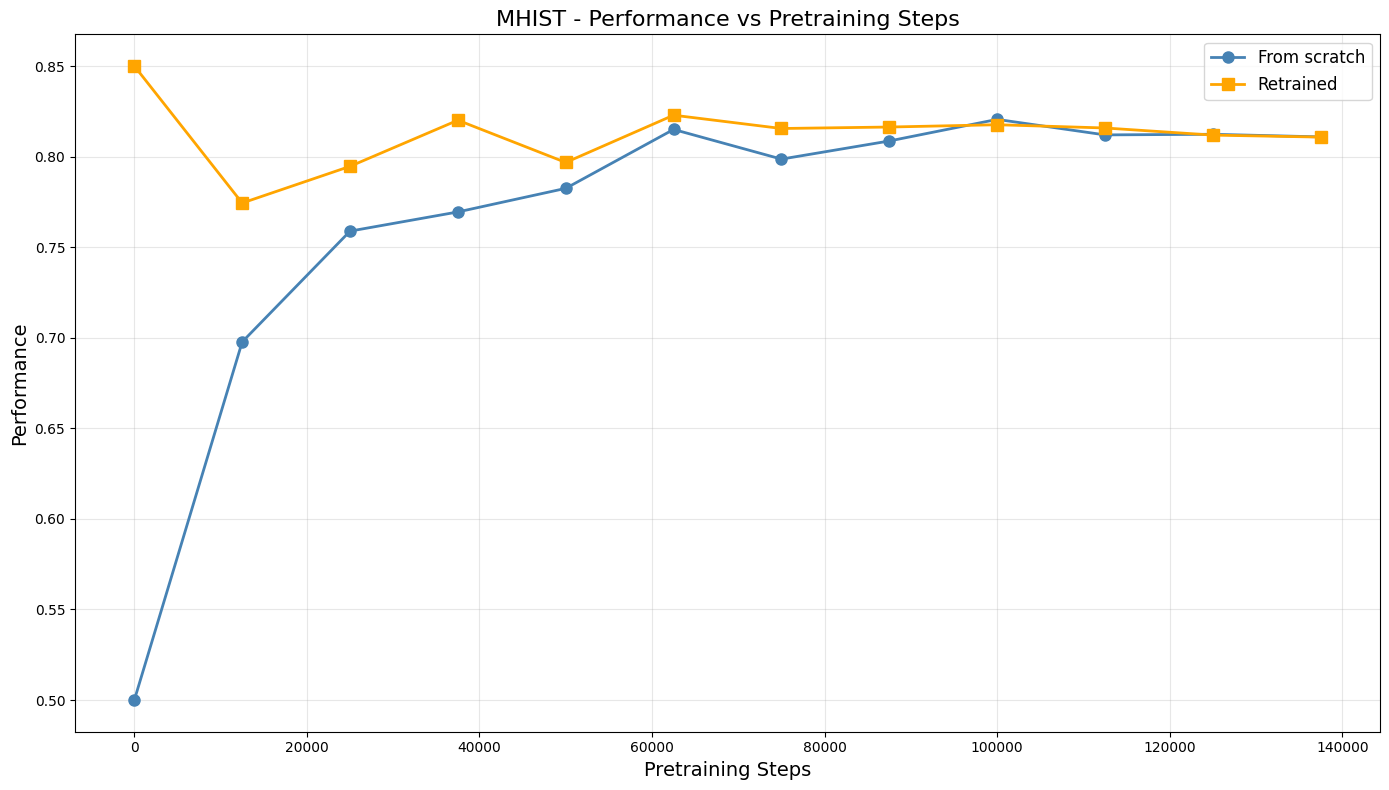

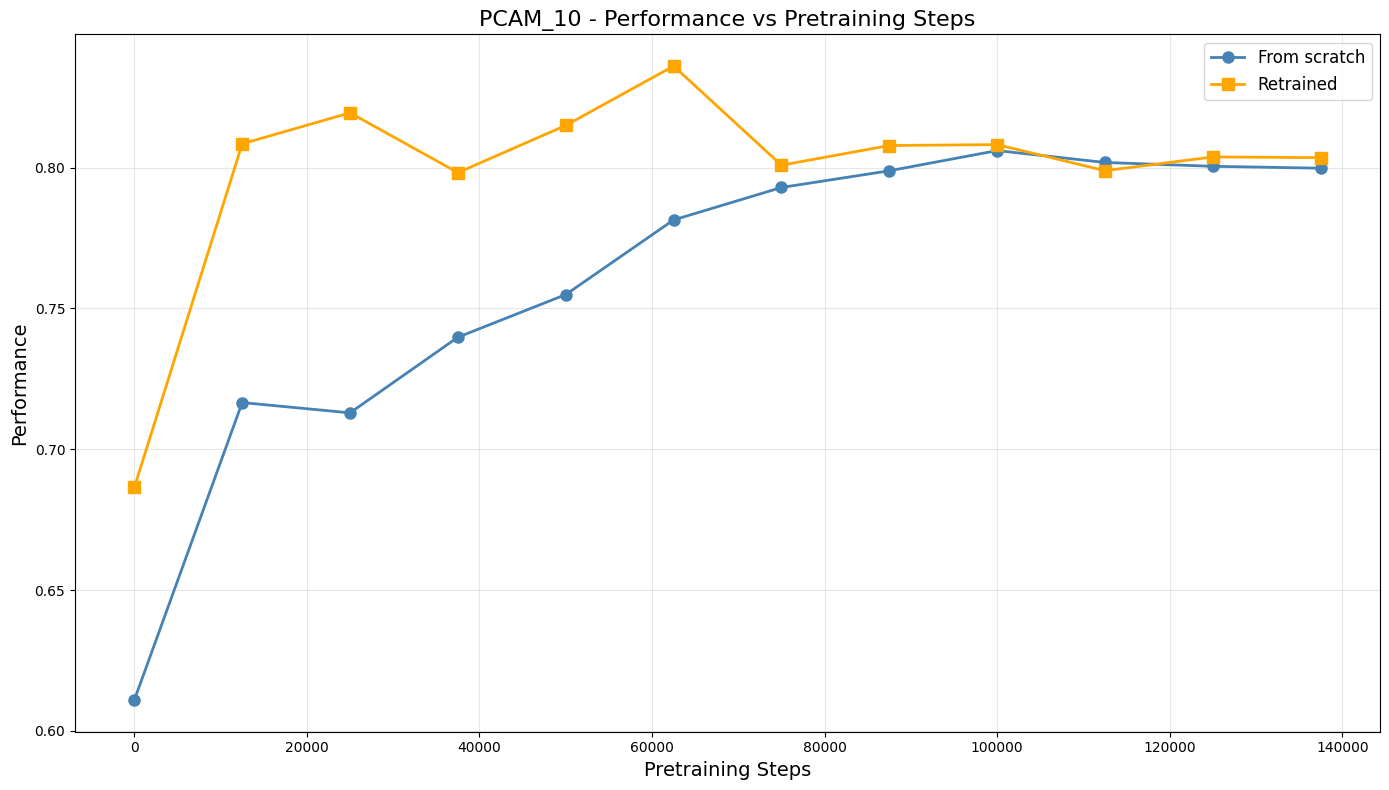

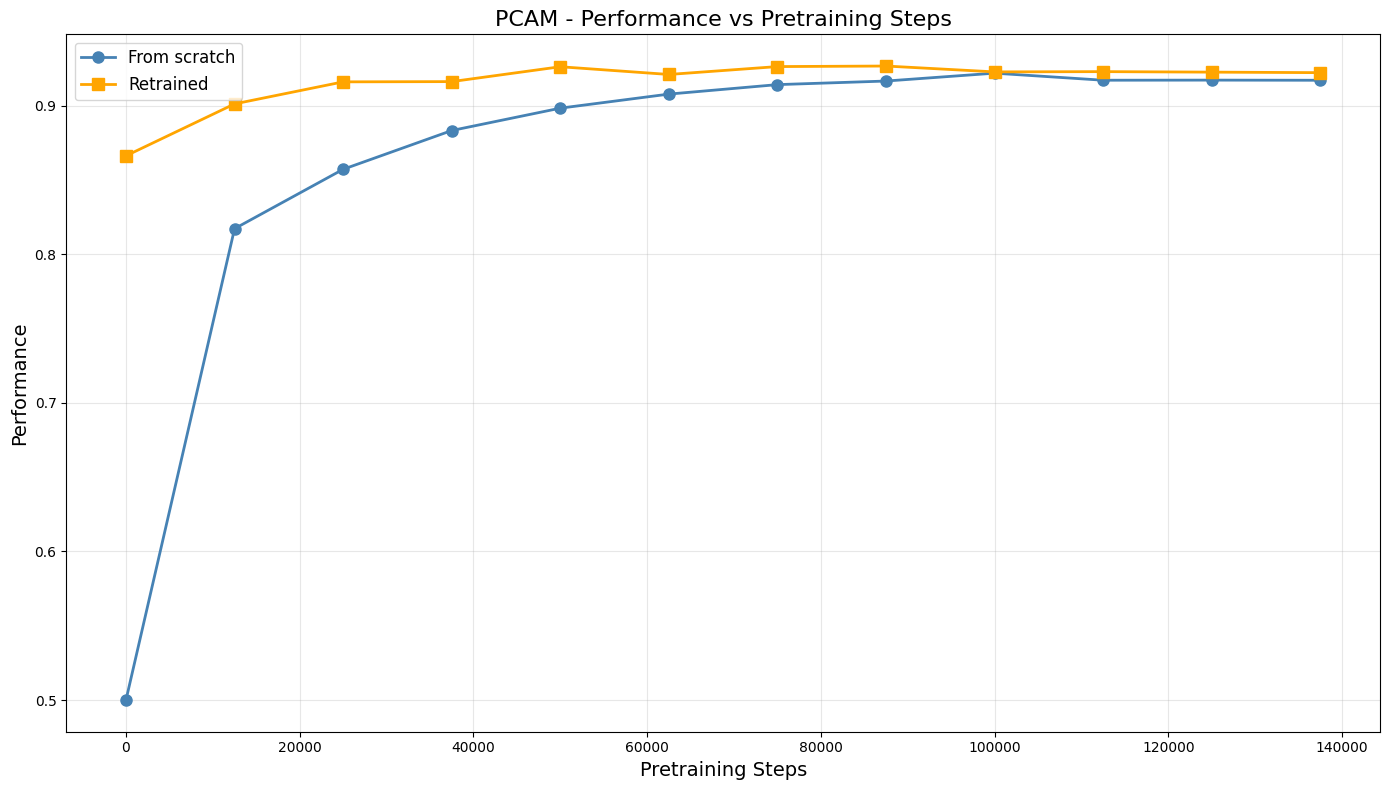

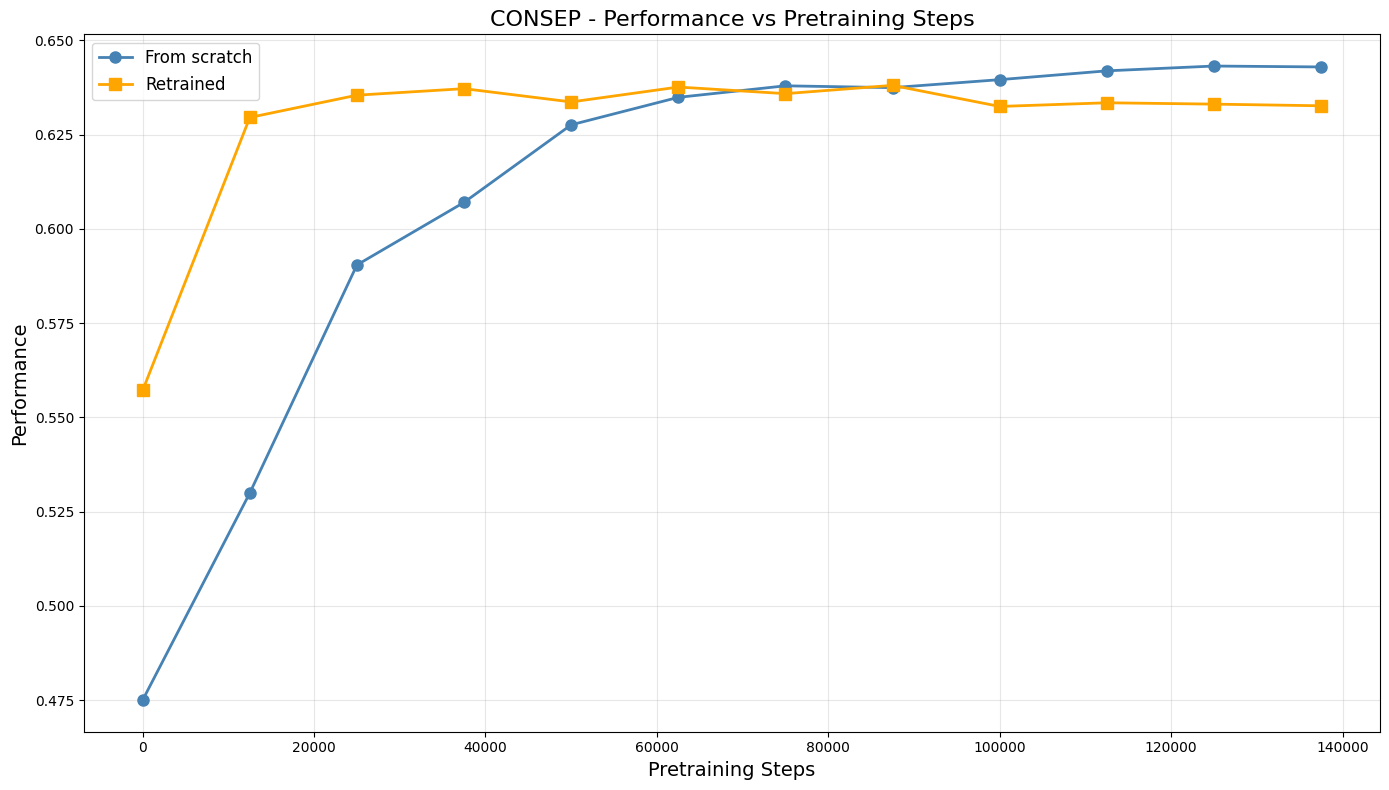

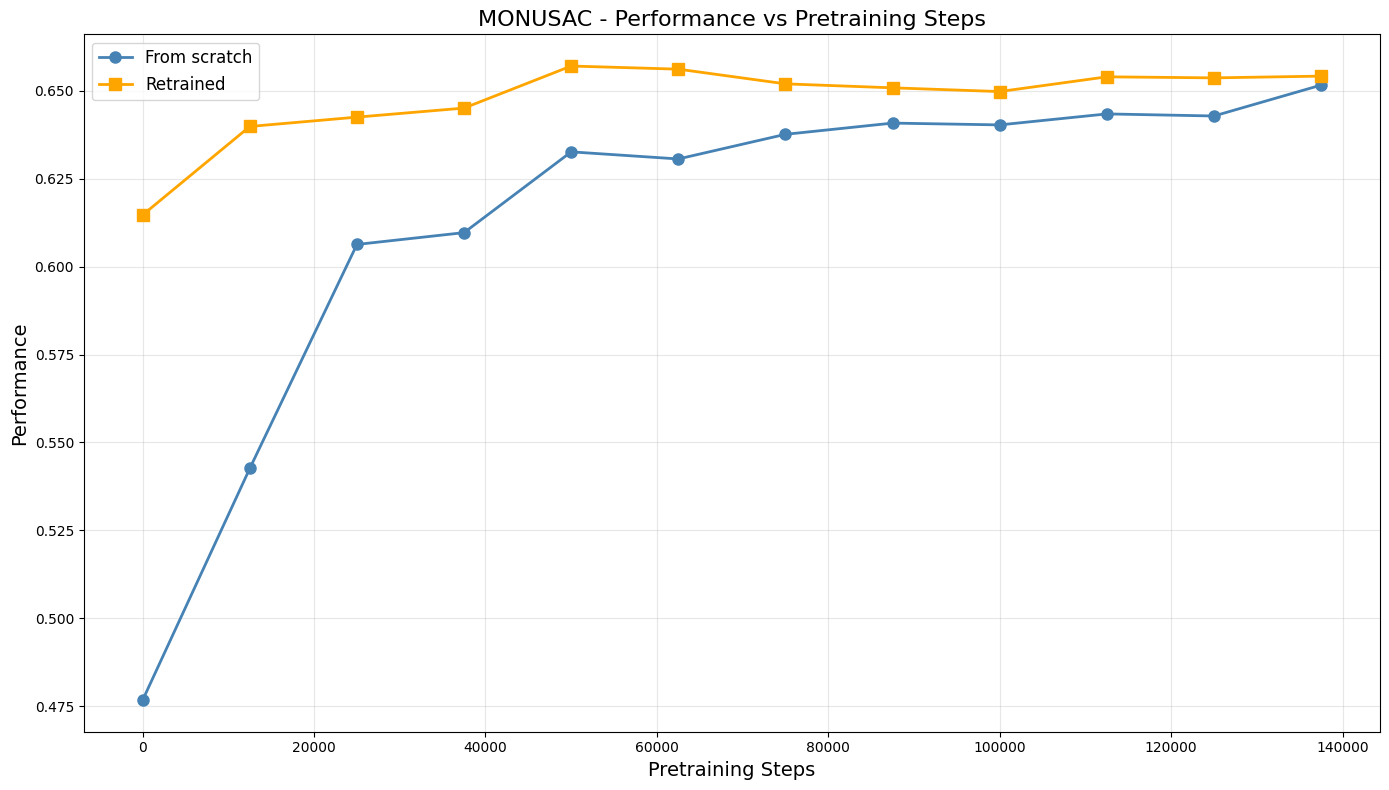

Saved 10 comparison plots


In [4]:
# Plot per-dataset comparison
individual_df = combined_df.dropna(subset=['metric_mean']).copy()
individual_df["step"] = individual_df["step"].astype(int)
individual_df = individual_df[individual_df["step"] <= 137500]  # Filter out steps greater than 137.5k
individual_df = individual_df.sort_values('step')
individual_df = individual_df.drop_duplicates(subset=["dataset", "step", "config"])

datasets = individual_df["dataset"].unique()

for dataset in datasets:
    dataset_data = individual_df[individual_df["dataset"] == dataset]
    
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Plot original config
    og_data = dataset_data[dataset_data["config"] == "original"].sort_values("step")
    ax.plot(og_data["step"], og_data["metric_mean"], 
            marker='o', linewidth=2, markersize=8, 
            label='From scratch', color='steelblue')
    
    # Plot retrained config
    retrain_data = dataset_data[dataset_data["config"] == "retrained"].sort_values("step")
    ax.plot(retrain_data["step"], retrain_data["metric_mean"], 
            marker='s', linewidth=2, markersize=8, 
            label='Retrained', color='orange')
    
    ax.set_xlabel('Pretraining Steps', fontsize=14)
    ax.set_ylabel('Performance', fontsize=14)
    ax.set_title(f'{dataset.upper()} - Performance vs Pretraining Steps', 
                 fontsize=16)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=12)
    
    plt.tight_layout()
    # plt.savefig(f'{dataset}_og_vs_retrained.png', dpi=300, bbox_inches='tight')
    plt.show()

print(f"Saved {len(datasets)} comparison plots")

In [ ]:
# Check for any other failures
failed = combined_df[combined_df['status'] == 'fail']
print(f"Failed evaluations: {len(failed)}")
print(failed[['dataset', 'step', 'config', 'status']])

In [ ]:
# After filtering to 137.5K
consep_data = individual_df[individual_df['dataset'] == 'consep']
print(f"CoNSeP data points: {len(consep_data)}")
print(f"CoNSeP steps: {sorted(consep_data['step'].unique())}")
print(f"CoNSeP configs: {consep_data['config'].value_counts()}")

# Check original vs retrained
consep_og = consep_data[consep_data['config'] == 'original']
consep_rt = consep_data[consep_data['config'] == 'retrained']

print(f"\nOriginal CoNSeP:")
print(consep_og[['step', 'metric_mean']].sort_values('step'))

print(f"\nRetrained CoNSeP:")
print(consep_rt[['step', 'metric_mean']].sort_values('step'))

The End